# Regularization

Regularization adds a **penalty on the size of the model coefficients** to the training loss, so
the optimizer is no longer free to chase every wiggle in the training data.

This notebook takes every term from the Ridge / Lasso discussion and shows it as **runnable
PySpark code**:

| # | Term | Section |
|---|------|---------|
| 1 | Training data with a *known* ground truth | 1 |
| 2 | The regularized objective: `regParam` ($\lambda$) and `elasticNetParam` ($\alpha$) | 2 |
| 3 | **Penalty term**: L1 norm vs. L2 norm | 3 |
| 4 | **Coefficient shrinkage** vs. **variable selection** (sparsity) | 4 |
| 5 | **Handling of correlated predictors** / grouping effect | 5 |
| 6 | **Computational considerations**: closed form vs. iterative solver | 6 |
| 7 | **Bias-variance trade-off**, measured | 7 |
| 8 | **Interpretability and model complexity** | 8 |
| 9 | Feature scale and the `standardization` parameter | 9 |
| 10 | Choosing $\lambda$ and $\alpha$ with cross-validation | 10 |
| 11 | The same knobs in other MLlib models (`LogisticRegression`) | 11 |

Everything - the data, the fits, the metrics and every summary table - is computed with Spark:
DataFrame aggregations, `groupBy` / `pivot` / `join`, window functions, `RDD.treeAggregate`,
`RegressionEvaluator` and `CrossValidator`.

In [1]:
# import findspark
# findspark.init()
from pyspark import SparkContext
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Regularization")
    .master("local[1]")
    .config("spark.sql.shuffle.partitions", "1")
    .config("spark.default.parallelism", "1")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.adaptive.enabled", "false")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 3.5.8


In [2]:
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator

# numpy is used ONLY for the small p x p linear algebra on the driver in Section 6,
# matplotlib ONLY to plot results that Spark has already computed.
import numpy as np
import matplotlib.pyplot as plt

## 1. A dataset where we know the true coefficients

Regularization is only *visible* if you know what the right answer is, so we generate the data in
Spark from a model we choose ourselves:

$$ y = 3\,x_1 - 2\,x_2 + 1.5\,x_3 + \varepsilon, \qquad \varepsilon \sim N(0,1) $$

The design deliberately contains the three situations Ridge and Lasso react to differently:

* **`x1`, `x2`, `x3`** - the real signal (true coefficients 3, -2, 1.5);
* **`x1_dup`** - a *near duplicate* of `x1` (correlation $\approx 0.999$), carrying no extra
  information: the **correlated predictors** case;
* **`noise1 ... noise16`** - pure noise, true coefficient 0. A good model should drop them.

One more design choice matters: we **train on only ~60 rows** and keep the rest for testing.
Regularization is a cure for *overfitting*, and overfitting needs a training set that is small
relative to the number of features - here **20 features and 63 training rows**. With 100 000 rows
and 20 features every penalty would only hurt.

In [3]:
N = 2000
N_NOISE = 16

SIGNAL    = ["x1", "x2", "x3"]                                  # truly useful
REDUNDANT = ["x1_dup"]                                          # a near copy of x1
NOISE     = [f"noise{i}" for i in range(1, N_NOISE + 1)]        # pure noise

# true coefficients: only x1, x2, x3 drive y
TRUE_BETA = {"x1": 3.0, "x1_dup": 0.0, "x2": -2.0, "x3": 1.5}
TRUE_BETA.update({c: 0.0 for c in NOISE})

FEATURES = list(TRUE_BETA)       # column order used everywhere below
LABEL = "y"
ZERO = 1e-10                     # anything below this counts as "exactly zero"

# the ground truth as a Spark DataFrame -- every later table is JOINed against it
ROLE = {c: ("signal" if c in SIGNAL else "redundant" if c in REDUNDANT else "noise")
        for c in FEATURES}

truth = spark.createDataFrame(
    [(i, c, float(TRUE_BETA[c]), ROLE[c]) for i, c in enumerate(FEATURES)],
    ["fid", "feature", "true_beta", "role"]).cache()

print(len(FEATURES), "features")
truth.show(6)

20 features


+---+-------+---------+---------+
|fid|feature|true_beta|     role|
+---+-------+---------+---------+
|  0|     x1|      3.0|   signal|
|  1| x1_dup|      0.0|redundant|
|  2|     x2|     -2.0|   signal|
|  3|     x3|      1.5|   signal|
|  4| noise1|      0.0|    noise|
|  5| noise2|      0.0|    noise|
+---+-------+---------+---------+
only showing top 6 rows



In [4]:
raw = spark.range(N)

for i, c in enumerate(SIGNAL + NOISE):                 # independent N(0,1) columns
    raw = raw.withColumn(c, F.randn(seed=i + 1))

raw = (raw
       # a near-copy of x1 -> the "correlated predictors" case
       .withColumn("x1_dup", F.col("x1") + F.lit(0.05) * F.randn(seed=101))
       # the response: x1_dup and the noise columns do NOT appear here
       .withColumn(LABEL, 3.0 * F.col("x1")
                          - 2.0 * F.col("x2")
                          + 1.5 * F.col("x3")
                          + F.randn(seed=102))
       .select(*FEATURES, LABEL))

raw.select("x1", "x1_dup", "x2", "x3", "noise1", "noise2", LABEL).show(5)

+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+------------------+
|                  x1|              x1_dup|                 x2|                  x3|              noise1|              noise2|                 y|
+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+------------------+
|  1.6845611254444919|   1.597902392531984| 0.2637682686300013| -1.1854930781734352| -1.1081822375859998|  1.5298496477243015|2.3785921965051866|
|  1.2276070094376463|  1.2424819149119863|-1.8126256284429794|  0.8301167121353836|-0.22945432308935576|  0.2517460544935095| 8.983275353676904|
|  0.7360632906893385|  0.6281725040491427|-0.3843556241621501| 0.11523977257141632|-0.20525069815326377|-0.07538978960066034|2.2736626458964877|
|    0.45082574888574| 0.48596270228711025|-3.0799742656179396| 0.05997281649929846|-0.00729422669818...|-0.2154036801598214

In [5]:
# how strongly are the predictors correlated?  (Spark scans the whole dataset)
print("corr(x1, x1_dup) = %.5f" % raw.stat.corr("x1", "x1_dup"))
print("corr(x1, x2)     = %.5f" % raw.stat.corr("x1", "x2"))
print("corr(x1, noise1) = %.5f" % raw.stat.corr("x1", "noise1"))

# every predictor has (roughly) unit variance -> coefficients are directly comparable
raw.select([F.round(F.stddev_pop(c), 3).alias(c)
            for c in ["x1", "x1_dup", "x2", "x3", "noise1", LABEL]]).show()

corr(x1, x1_dup) = 0.99881
corr(x1, x2)     = -0.01176


corr(x1, noise1) = 0.00496


+-----+------+-----+-----+------+----+
|   x1|x1_dup|   x2|   x3|noise1|   y|
+-----+------+-----+-----+------+----+
|0.999| 1.001|0.984|0.976| 0.992|3.92|
+-----+------+-----+-----+------+----+



In [6]:
# MLlib expects one vector column holding all the predictors
assembler = VectorAssembler(inputCols=FEATURES, outputCol="features")
data = assembler.transform(raw).cache()

# small TRAIN set (so that overfitting is possible), large TEST set (so the test error is reliable)
train, test = data.randomSplit([0.03, 0.97], seed=42)
train.cache(); test.cache()

n_train = train.count()

# sigma_y of the TRAINING label: Spark standardizes the label internally, we need it in Section 2
SIGMA_Y = train.select(F.stddev_pop(LABEL)).first()[0]

print("train rows:", n_train, "   test rows:", test.count(),
      "   features:", len(FEATURES), "   sigma_y = %.4f" % SIGMA_Y)
train.select("features", LABEL).show(3, truncate=70)

train rows: 63    test rows: 1937    features: 20    sigma_y = 3.5582
+----------------------------------------------------------------------+------------------+
|                                                              features|                 y|
+----------------------------------------------------------------------+------------------+
|[-2.338723437802424,-2.3408824303473246,0.14406451330618975,0.28375...|-5.814079245414676|
|[-1.6464830122277085,-1.664686097119847,1.6944072813369617,-0.92858...| -9.78170591339673|
|[-1.635151680121888,-1.6989438247045718,-0.14035650627106144,-0.952...|-6.110945734976916|
+----------------------------------------------------------------------+------------------+
only showing top 3 rows



## 2. The regularized objective: `regParam` = $\lambda$, `elasticNetParam` = $\alpha$

An **un-regularized** least squares fit minimizes only the *data loss*

$$ L_{\text{data}}(\beta) \;=\; \frac{1}{2n}\sum_{i=1}^{n}\bigl(y_i-\hat y_i\bigr)^2 $$

MLlib's `LinearRegression` adds an **elastic-net penalty** on top of it:

$$ L(\beta) \;=\; \underbrace{\frac{1}{2n}\sum_i (y_i-\hat y_i)^2}_{\text{fit the data}}
   \;+\; \underbrace{\lambda\Bigl[\alpha\underbrace{\textstyle\sum_j|\beta_j|}_{L_1}
   \;+\;\frac{1-\alpha}{2}\underbrace{\textstyle\sum_j\beta_j^2}_{L_2}\Bigr]}_{\text{keep }\beta\text{ small}} $$

Two knobs control everything:

| Spark parameter | Symbol | Meaning |
|---|---|---|
| `regParam`        | $\lambda$ | **how much** regularization (0 = none, larger = stronger) |
| `elasticNetParam` | $\alpha$  | **which kind**: `0.0` = pure **Ridge / L2**, `1.0` = pure **Lasso / L1**, in between = **Elastic Net** |

Two details that are easy to miss:

* the **intercept is never penalized** - it only shifts predictions, it does not add complexity;
* `standardization=True` by default, so the penalty is applied to the coefficients of
  *standardized* features (Section 9).

In [7]:
# ---- the helpers the whole notebook is built on -------------------------------------------------

#   reg_param = lambda  (regParam)
#   alpha     = 0 -> Ridge, 1 -> Lasso, 0 < alpha < 1 -> Elastic Net  (elasticNetParam)
def fit_lr(reg_param=0.0, alpha=0.0, df=None, standardization=True, maxIter=500, **kwargs):
    lr = LinearRegression(featuresCol="features", labelCol=LABEL,
                          regParam=reg_param,          # lambda
                          elasticNetParam=alpha,       # alpha
                          standardization=standardization,
                          maxIter=maxIter,             # default is 100; L1 needs more here (Sec. 6)
                          **kwargs)
    return lr.fit(train if df is None else df)


# fitted coefficient vectors -> a Spark DataFrame (model, fid, feature, beta) in LONG format,
# so that every table below is a groupBy / pivot / join done by Spark
def coefs_of(models):
    rows = [(name, i, FEATURES[i], float(b))
            for name, m in models.items()
            for i, b in enumerate(m.coefficients.toArray())]
    return spark.createDataFrame(rows, ["model", "fid", "feature", "beta"])


# LONG -> WIDE: one column per model, features kept in their original order
def wide(coefs, keys, key_col="model", value="beta", nd=4):
    return (coefs.withColumn(value, F.round(F.col(value), nd))
                 .groupBy("fid", "feature").pivot(key_col, keys).agg(F.first(value)))


def show_with_truth(w, n=25):
    (truth.select("fid", "feature", F.round("true_beta", 1).alias("TRUE"))
          .join(w.drop("feature"), "fid")
          .orderBy("fid").drop("fid").show(n, truncate=False))


def rmse(model, df):
    return RegressionEvaluator(labelCol=LABEL, predictionCol="prediction",
                               metricName="rmse").evaluate(model.transform(df))

In [8]:
# lambda = 0  ->  ordinary least squares, no penalty at all
ols   = fit_lr(reg_param=0.0)
ridge = fit_lr(reg_param=0.3, alpha=0.0)   # L2 only
enet  = fit_lr(reg_param=0.3, alpha=0.5)   # half and half
lasso = fit_lr(reg_param=0.3, alpha=1.0)   # L1 only

MODELS = {"OLS_l0": ols, "Ridge_a0_l0.3": ridge, "ENet_a0.5_l0.3": enet, "Lasso_a1_l0.3": lasso}
coefs4 = coefs_of(MODELS).cache()

show_with_truth(wide(coefs4, list(MODELS)))

+-------+----+-------+-------------+--------------+-------------+
|feature|TRUE|OLS_l0 |Ridge_a0_l0.3|ENet_a0.5_l0.3|Lasso_a1_l0.3|
+-------+----+-------+-------------+--------------+-------------+
|x1     |3.0 |3.5458 |1.4087       |1.3167        |0.3425       |
|x1_dup |0.0 |-0.5152|1.3868       |1.3586        |2.2401       |
|x2     |-2.0|-1.9803|-1.7273      |-1.626        |-1.5253      |
|x3     |1.5 |1.3472 |1.1448       |1.0824        |0.9526       |
|noise1 |0.0 |-0.0412|-0.1066      |-0.0326       |0.0          |
|noise2 |0.0 |0.1895 |0.1871       |0.0799        |0.0          |
|noise3 |0.0 |-0.1476|-0.1415      |-0.0304       |0.0          |
|noise4 |0.0 |-0.0249|0.0721       |0.0           |0.0          |
|noise5 |0.0 |0.1383 |0.1315       |0.0           |0.0          |
|noise6 |0.0 |0.0571 |0.006        |0.0           |0.0          |
|noise7 |0.0 |0.1184 |0.0695       |0.0           |0.0          |
|noise8 |0.0 |0.1287 |0.1191       |0.0           |0.0          |
|noise9 |0

Already visible in that table: OLS puts non-zero weight on **every** noise column - with only 63
rows there is always some accidental correlation to exploit. Ridge shrinks those weights, and Lasso
drives them to **exactly 0**. (`x1_dup` is the one both methods struggle with; Section 5.)

### The two halves of the objective, computed with Spark

`L_data` is a distributed aggregation over the rows; the norms of $\beta$ are a `groupBy` over the
coefficient DataFrame. Both halves, for all four models:

In [9]:
# (1/2n) * SUM (y - yhat)^2  -- a Spark aggregation over the whole training set
def data_loss(model, df):
    n = df.count()
    sse = (model.transform(df)
                .select(F.sum(F.pow(F.col(LABEL) - F.col("prediction"), 2)).alias("sse"))
                .first()["sse"])
    return sse / (2.0 * n)


# the (lambda, alpha) each model was fitted with, plus its data loss
settings = spark.createDataFrame(
    [(0, "OLS_l0",         0.0, 0.0, data_loss(ols,   train)),
     (1, "Ridge_a0_l0.3",  0.3, 0.0, data_loss(ridge, train)),
     (2, "ENet_a0.5_l0.3", 0.3, 0.5, data_loss(enet,  train)),
     (3, "Lasso_a1_l0.3",  0.3, 1.0, data_loss(lasso, train))],
    ["idx", "model", "lambda", "alpha", "L_data"])

# the two norms of every coefficient vector -- a groupBy over the LONG coefficient DataFrame
norms = coefs4.groupBy("model").agg(F.sum(F.abs("beta")).alias("l1"),
                                    F.sum(F.col("beta") ** 2).alias("l2sq"))

(settings.join(norms, "model")
         .withColumn("penalty", F.col("lambda") * (F.col("alpha") * F.col("l1")
                                                   + (1 - F.col("alpha")) / 2 * F.col("l2sq")))
         .withColumn("total", F.col("L_data") + F.col("penalty"))
         .orderBy("idx")
         .select("model", "lambda", "alpha",
                 F.round("L_data", 4).alias("L_data"),
                 F.round("l1", 4).alias("norm_L1"),
                 F.round("l2sq", 4).alias("norm_L2_sq"),
                 F.round("penalty", 4).alias("penalty"),
                 F.round("total", 4).alias("TOTAL"))
         .show(truncate=False))

+--------------+------+-----+------+-------+----------+-------+------+
|model         |lambda|alpha|L_data|norm_L1|norm_L2_sq|penalty|TOTAL |
+--------------+------+-----+------+-------+----------+-------+------+
|OLS_l0        |0.0   |0.0  |0.2982|9.0424 |18.8157   |0.0    |0.2982|
|Ridge_a0_l0.3 |0.3   |0.0  |0.3408|6.9871 |8.3528    |1.2529 |1.5937|
|ENet_a0.5_l0.3|0.3   |0.5  |0.4472|5.5265 |7.4032    |1.3842 |1.8314|
|Lasso_a1_l0.3 |0.3   |1.0  |0.5521|5.0605 |8.3691    |1.5181 |2.0702|
+--------------+------+-----+------+-------+----------+-------+------+



Read the table left to right:

* **OLS has the smallest `L_data`** - by definition, nothing fits the *training* data better than
  unpenalized least squares.
* Every regularized model has a **larger `L_data` but a smaller $\|\beta\|$**. That is the whole
  trade: a slightly worse fit on the training data in exchange for a smaller, more stable model.
  Section 7 shows that this trade pays off on *test* data.

### What does `regParam` really multiply? (verify, do not trust)

Spark standardizes the label internally, which makes the **effective L2 strength**
$\lambda/\sigma_y$ rather than $\lambda$. Instead of taking that on faith we *test* it: at a
minimum, **no** small perturbation $\beta + d$ may lower the objective. The perturbed objective is
evaluated with Spark - the SSE of an arbitrary coefficient vector is just a column expression.

In [10]:
# SUM (y - (b0 + x.beta))^2 evaluated in Spark for ANY coefficient vector
def sse_spark(beta, intercept, df):
    pred = F.lit(float(intercept))
    for b, c in zip(beta, FEATURES):
        pred = pred + F.lit(float(b)) * F.col(c)
    return df.select(F.sum(F.pow(F.col(LABEL) - pred, 2))).first()[0]


def objective(beta, intercept, df, n, l1_coef, l2_coef):
    return (sse_spark(beta, intercept, df) / (2.0 * n)
            + l1_coef * sum(abs(b) for b in beta)
            + l2_coef / 2.0 * sum(b * b for b in beta))


lam, alpha = 0.5, 0.0                        # pure Ridge, standardization switched off
m = fit_lr(lam, alpha, standardization=False)
beta, b0 = m.coefficients.toArray(), m.intercept

rng = np.random.default_rng(0)
directions = [rng.normal(size=len(FEATURES)) * 0.02 for _ in range(15)]

for label, l2_coef in [("textbook:  lambda*(1-a)",         lam * (1 - alpha)),
                       ("Spark:     lambda*(1-a)/sigma_y", lam * (1 - alpha) / SIGMA_Y)]:
    base = objective(beta, b0, train, n_train, 0.0, l2_coef)
    worse = sum(objective(beta + d, b0, train, n_train, 0.0, l2_coef) < base - 1e-12
                for d in directions)
    print(f"{label:34s} L(beta_hat) = {base:8.5f}   perturbations that BEAT it: {worse}/15")

textbook:  lambda*(1-a)            L(beta_hat) =  2.21411   perturbations that BEAT it: 3/15


Spark:     lambda*(1-a)/sigma_y    L(beta_hat) =  0.91001   perturbations that BEAT it: 0/15


`0/15` means the fitted $\hat\beta$ really is the minimum of that objective; anything else means we
wrote down the wrong objective. The $\lambda/\sigma_y$ version wins, so **Spark effectively
minimizes**

$$ \frac{1}{2n}\sum_i (y_i-\hat y_i)^2 \;+\; \lambda\alpha\sum_j|\beta_j|
   \;+\; \frac{\lambda(1-\alpha)}{2\,\sigma_y}\sum_j\beta_j^2 $$

Practical consequence: `regParam=0.5` does **not** mean the same amount of shrinkage on two
datasets whose labels have different spread. Always tune $\lambda$ per dataset (Section 10).

## 3. Penalty term: L1 norm vs. L2 norm

* **Ridge / L2**, $\lambda\sum_j\beta_j^2$: squaring means a coefficient of 4 costs 16x more than a
  coefficient of 1, so L2 fights hard against *large* coefficients and barely notices small ones.
  Its gradient $2\lambda\beta_j$ vanishes as $\beta_j\to 0$, so the last step to exactly zero is
  never taken.
* **Lasso / L1**, $\lambda\sum_j|\beta_j|$: the cost per unit is *constant*, so the pressure towards
  zero stays at $\lambda$ no matter how small $\beta_j$ already is. As soon as a feature's
  contribution to the data loss is worth less than $\lambda$, its coefficient is pinned at
  exactly **0**.

How much does each single coefficient contribute to each penalty? A Spark **window function** over
the whole coefficient DataFrame turns the costs into shares of the total.

In [11]:
all_rows = Window.partitionBy()      # an empty window spec = one group = the global total

(coefs_of({"OLS": ols})
    .withColumn("l1_cost", F.abs("beta"))
    .withColumn("l2_cost", F.col("beta") ** 2)
    .withColumn("share_L1_pct", 100 * F.col("l1_cost") / F.sum("l1_cost").over(all_rows))
    .withColumn("share_L2_pct", 100 * F.col("l2_cost") / F.sum("l2_cost").over(all_rows))
    .orderBy("fid")
    .select("feature",
            F.round("beta", 4).alias("beta_OLS"),
            F.round("l1_cost", 4).alias("L1_cost_abs_b"),
            F.round("l2_cost", 4).alias("L2_cost_b_sq"),
            F.round("share_L1_pct", 2).alias("share_L1_pct"),
            F.round("share_L2_pct", 2).alias("share_L2_pct"))
    .show(25, truncate=False))

+-------+--------+-------------+------------+------------+------------+
|feature|beta_OLS|L1_cost_abs_b|L2_cost_b_sq|share_L1_pct|share_L2_pct|
+-------+--------+-------------+------------+------------+------------+
|x1     |3.5458  |3.5458       |12.5729     |39.21       |66.82       |
|x1_dup |-0.5152 |0.5152       |0.2654      |5.7         |1.41        |
|x2     |-1.9803 |1.9803       |3.9216      |21.9        |20.84       |
|x3     |1.3472  |1.3472       |1.8151      |14.9        |9.65        |
|noise1 |-0.0412 |0.0412       |0.0017      |0.46        |0.01        |
|noise2 |0.1895  |0.1895       |0.0359      |2.1         |0.19        |
|noise3 |-0.1476 |0.1476       |0.0218      |1.63        |0.12        |
|noise4 |-0.0249 |0.0249       |6.0E-4      |0.28        |0.0         |
|noise5 |0.1383  |0.1383       |0.0191      |1.53        |0.1         |
|noise6 |0.0571  |0.0571       |0.0033      |0.63        |0.02        |
|noise7 |0.1184  |0.1184       |0.014       |1.31        |0.07  

The big coefficients dominate the **L2** column, while the many small noise coefficients are almost
invisible to it. In the **L1** column those small coefficients keep a much larger share - which is
exactly why L1, and not L2, is the norm that removes them.

In [12]:
# Fit the whole regularization path once; keep every coefficient in ONE long Spark DataFrame.
lambdas = [0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
LKEYS = [f"{l:g}" for l in lambdas]           # column names for the pivots below
KINDS = ["ridge", "lasso"]

fits = {(kind, lam): fit_lr(lam, a)
        for kind, a in [("ridge", 0.0), ("lasso", 1.0)]
        for lam in lambdas}

paths = spark.createDataFrame(
    [(kind, float(lam), f"{lam:g}", i, FEATURES[i], float(b))
     for (kind, lam), m in fits.items()
     for i, b in enumerate(m.coefficients.toArray())],
    ["kind", "lam", "lamk", "fid", "feature", "beta"]).cache()

print("rows in the coefficient DataFrame:", paths.count(),
      f"  ({len(KINDS)} models x {len(lambdas)} lambdas x {len(FEATURES)} features)")

# both norms for every model, in one grouped aggregation
(paths.groupBy("lam")
      .pivot("kind", KINDS)
      .agg(F.round(F.sum(F.abs("beta")), 4).alias("L1"),
           F.round(F.sum(F.col("beta") ** 2), 4).alias("L2sq"))
      .orderBy("lam").show())

rows in the coefficient DataFrame: 360   (2 models x 9 lambdas x 20 features)


+-----+--------+----------+--------+----------+
|  lam|ridge_L1|ridge_L2sq|lasso_L1|lasso_L2sq|
+-----+--------+----------+--------+----------+
|  0.0|  9.0424|   18.8157|  9.0424|   18.8157|
|0.001|  8.1213|   15.5278|  7.9653|   15.1034|
|0.003|  7.9709|   12.8808|  7.8978|   15.0098|
| 0.01|  7.9275|   10.9497|  7.6767|   14.6975|
| 0.03|  7.8307|   10.3025|  7.1452|   13.0166|
|  0.1|  7.5607|    9.6578|  6.0618|    8.6457|
|  0.3|  6.9871|    8.3528|  5.0605|    8.3691|
|  1.0|  6.0432|    5.7461|  2.5114|    3.8833|
|  3.0|  4.9918|    3.0668|     0.0|       0.0|
+-----+--------+----------+--------+----------+



Both norms fall as $\lambda$ grows - that *is* what "shrinkage" means, and Lasso shrinks the L1
norm much faster than Ridge does.

A practical note on `maxIter`: with Spark's default of 100 iterations the L1 solver stops **before**
converging on this data (the near-identical twins `x1` / `x1_dup` make the objective very flat in
one direction), and the path comes out visibly wobbly. `fit_lr` therefore uses `maxIter=500` - see
the iteration counts in Section 6.

## 4. Coefficient shrinkage vs. variable selection

This is the headline difference:

* **Ridge shrinks continuously** - every coefficient moves towards zero as $\lambda$ grows, but
  **none becomes exactly zero**, so all 20 predictors stay in the model.
* **Lasso selects** - coefficients hit **exactly 0** one after another, which removes the feature
  from the model entirely.

The *coefficient path* (coefficients as a function of $\lambda$) shows both behaviours at a glance.
A `pivot` on $\lambda$ turns the long DataFrame into the usual path table.

In [13]:
def path_table(kind):
    return (paths.filter(F.col("kind") == kind)
                 .withColumn("beta", F.round("beta", 3))
                 .groupBy("fid", "feature").pivot("lamk", LKEYS).agg(F.first("beta"))
                 .orderBy("fid").drop("fid"))

print("RIDGE coefficient path   (columns = regParam)")
path_table("ridge").show(25, truncate=False)
print("LASSO coefficient path   (columns = regParam)")
path_table("lasso").show(25, truncate=False)

RIDGE coefficient path   (columns = regParam)


+-------+------+------+------+------+------+------+------+------+------+
|feature|0     |0.001 |0.003 |0.01  |0.03  |0.1   |0.3   |1     |3     |
+-------+------+------+------+------+------+------+------+------+------+
|x1     |3.546 |3.095 |2.607 |2.033 |1.706 |1.53  |1.409 |1.208 |0.926 |
|x1_dup |-0.515|-0.064|0.424 |0.994 |1.304 |1.418 |1.387 |1.215 |0.936 |
|x2     |-1.98 |-1.975|-1.969|-1.958|-1.937|-1.877|-1.727|-1.364|-0.876|
|x3     |1.347 |1.343 |1.338 |1.328 |1.311 |1.262 |1.145 |0.88  |0.556 |
|noise1 |-0.041|-0.044|-0.047|-0.051|-0.058|-0.074|-0.107|-0.157|-0.166|
|noise2 |0.19  |0.19  |0.191 |0.191 |0.191 |0.19  |0.187 |0.185 |0.171 |
|noise3 |-0.148|-0.147|-0.146|-0.144|-0.143|-0.142|-0.142|-0.141|-0.128|
|noise4 |-0.025|-0.024|-0.022|-0.018|-0.009|0.016 |0.072 |0.179 |0.247 |
|noise5 |0.138 |0.133 |0.128 |0.122 |0.12  |0.123 |0.132 |0.147 |0.147 |
|noise6 |0.057 |0.056 |0.055 |0.053 |0.048 |0.036 |0.006 |-0.055|-0.109|
|noise7 |0.118 |0.121 |0.125 |0.127 |0.124 |0.108 |

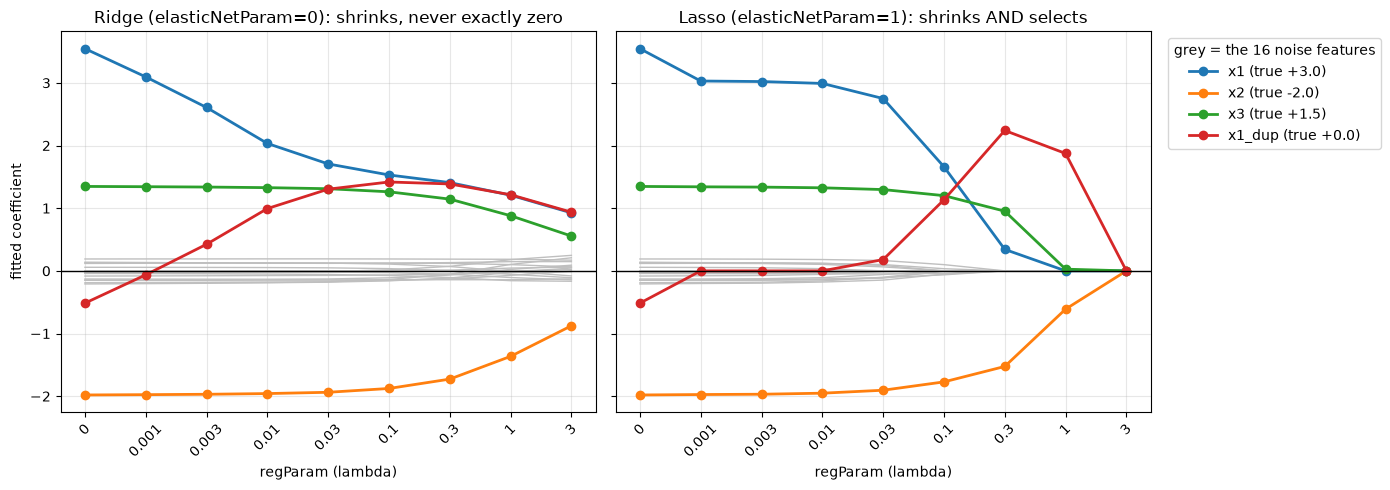

In [14]:
# Collect the (small) result of the Spark computation and plot it
rows = paths.select("kind", "lam", "feature", "beta").collect()
series = {}
for r in rows:
    series.setdefault((r["kind"], r["feature"]), {})[r["lam"]] = r["beta"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = list(range(len(lambdas)))
for ax, kind, title in zip(axes, KINDS,
                           ["Ridge (elasticNetParam=0): shrinks, never exactly zero",
                            "Lasso (elasticNetParam=1): shrinks AND selects"]):
    for c in NOISE:                                    # the noise features: grey, no legend entry
        ax.plot(x, [series[(kind, c)][l] for l in lambdas], color="0.75", lw=1)
    for c in SIGNAL + REDUNDANT:                       # the interesting ones
        ax.plot(x, [series[(kind, c)][l] for l in lambdas], "-o", lw=2,
                label=f"{c} (true {TRUE_BETA[c]:+.1f})")
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(LKEYS, rotation=45)
    ax.set_xlabel("regParam (lambda)"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("fitted coefficient")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left",
               title=f"grey = the {len(NOISE)} noise features")
plt.tight_layout(); plt.show()

In [15]:
# Count the coefficients that are EXACTLY zero -- the definition of sparsity.
is_zero    = F.when(F.abs("beta") <= ZERO, 1).otherwise(0)
is_nonzero = F.when(F.abs("beta") >  ZERO, 1).otherwise(0)

(paths.groupBy("lam")
      .pivot("kind", KINDS)
      .agg(F.sum(is_nonzero).alias("nonzero"), F.sum(is_zero).alias("zeros"))
      .orderBy("lam").show())

+-----+-------------+-----------+-------------+-----------+
|  lam|ridge_nonzero|ridge_zeros|lasso_nonzero|lasso_zeros|
+-----+-------------+-----------+-------------+-----------+
|  0.0|           20|          0|           20|          0|
|0.001|           20|          0|           19|          1|
|0.003|           20|          0|           19|          1|
| 0.01|           20|          0|           16|          4|
| 0.03|           20|          0|           16|          4|
|  0.1|           20|          0|           10|         10|
|  0.3|           20|          0|            4|         16|
|  1.0|           20|          0|            3|         17|
|  3.0|           20|          0|            0|         20|
+-----+-------------+-----------+-------------+-----------+



In [16]:
# WHICH features survive?  JOIN the coefficients with the roles we gave the columns in Section 1.
(paths.join(truth.select("feature", "role"), "feature")
      .groupBy("kind", "lam")
      .pivot("role", ["signal", "redundant", "noise"])
      .agg(F.sum(is_nonzero))
      .withColumnRenamed("signal", "signal_kept_of_3")
      .withColumnRenamed("redundant", "redundant_kept_of_1")
      .withColumnRenamed("noise", f"NOISE_kept_of_{len(NOISE)}")
      .orderBy("kind", "lam").show(20))

+-----+-----+----------------+-------------------+----------------+
| kind|  lam|signal_kept_of_3|redundant_kept_of_1|NOISE_kept_of_16|
+-----+-----+----------------+-------------------+----------------+
|lasso|  0.0|               3|                  1|              16|
|lasso|0.001|               3|                  0|              16|
|lasso|0.003|               3|                  0|              16|
|lasso| 0.01|               3|                  0|              13|
|lasso| 0.03|               3|                  1|              12|
|lasso|  0.1|               3|                  1|               6|
|lasso|  0.3|               3|                  1|               0|
|lasso|  1.0|               2|                  1|               0|
|lasso|  3.0|               0|                  0|               0|
|ridge|  0.0|               3|                  1|              16|
|ridge|0.001|               3|                  1|              16|
|ridge|0.003|               3|                  

Read the `lasso` block: as $\lambda$ grows Lasso throws the **noise features out first** and keeps
the real signal longest - that is *variable selection*. Push $\lambda$ too far (3.0) and it deletes
everything, including the signal. Ridge keeps all 16 noise features at every $\lambda$; it only
makes their coefficients smaller.

## 5. Handling of correlated predictors

`x1` and `x1_dup` are 99.9% correlated, and the truth puts weight **3.0 on `x1`, 0.0 on `x1_dup`**.
Any split of the total 3.0 between the two fits the data almost equally well, so the *penalty*, not
the data, decides what happens:

* **Ridge** minimizes $\beta_1^2+\beta_{1dup}^2$ subject to $\beta_1+\beta_{1dup}\approx 3$, and
  $1.5^2+1.5^2 < 3^2+0^2$ - so it **splits the weight evenly** ("grouping effect").
* **Lasso** sees $|\beta_1|+|\beta_{1dup}|$, which equals 3 for *every* split, so the tie is broken
  arbitrarily by the solver: it tends to **push the weight onto one of them**.
* **Elastic Net** ($0<\alpha<1$) mixes the two: sparse on unrelated features, but it keeps
  correlated groups together.

In [17]:
PAIR = ["x1", "x1_dup"]
SOME = [0.03, 0.1, 0.3, 1.0]

pair = (paths.filter(F.col("feature").isin(PAIR) & F.col("lam").isin(SOME))
             .withColumn("col", F.concat_ws("_", "kind", "feature")))

split = (pair.groupBy("lam")
             .pivot("col", ["ridge_x1", "ridge_x1_dup", "lasso_x1", "lasso_x1_dup"])
             .agg(F.round(F.first("beta"), 4)))

sums = (pair.groupBy("lam", "kind").agg(F.sum("beta").alias("s"))
            .groupBy("lam").pivot("kind", KINDS)
            .agg(F.round(F.first("s"), 4).alias("sum")))

print("true weight carried by the (x1, x1_dup) pair = 3.0")
split.join(sums, "lam").orderBy("lam").show()

true weight carried by the (x1, x1_dup) pair = 3.0


+----+--------+------------+--------+------------+------+------+
| lam|ridge_x1|ridge_x1_dup|lasso_x1|lasso_x1_dup| ridge| lasso|
+----+--------+------------+--------+------------+------+------+
|0.03|  1.7063|      1.3036|  2.7499|      0.1799|  3.01|2.9298|
| 0.1|  1.5304|      1.4182|  1.6613|      1.1341|2.9486|2.7954|
| 0.3|  1.4087|      1.3868|  0.3425|      2.2401|2.7956|2.5826|
| 1.0|  1.2076|      1.2148|     0.0|      1.8733|2.4224|1.8733|
+----+--------+------------+--------+------------+------+------+



In [18]:
# Stability under resampling: refit on bootstrap resamples (Spark `sample`) and watch the split move
boot_rows = []
for i in range(5):
    boot = train.sample(withReplacement=True, fraction=1.0, seed=100 + i)
    for kind, a in [("ridge", 0.0), ("lasso", 1.0)]:
        c = dict(zip(FEATURES, fit_lr(0.1, a, df=boot).coefficients.toArray()))
        boot_rows.append((i, kind, float(c["x1"]), float(c["x1_dup"])))

boots = (spark.createDataFrame(boot_rows, ["resample", "kind", "x1", "x1_dup"])
              .withColumn("sum", F.col("x1") + F.col("x1_dup")).cache())

(boots.groupBy("resample").pivot("kind", KINDS)
      .agg(F.round(F.first("x1"), 4).alias("x1"),
           F.round(F.first("x1_dup"), 4).alias("x1_dup"),
           F.round(F.first("sum"), 4).alias("sum"))
      .orderBy("resample").show())

print("spread across the 5 resamples:")
(boots.groupBy("kind")
      .agg(F.round(F.stddev("x1"), 4).alias("std_x1"),
           F.round(F.stddev("x1_dup"), 4).alias("std_x1_dup"),
           F.round(F.stddev("sum"), 4).alias("std_sum"))
      .show())

+--------+--------+------------+---------+--------+------------+---------+
|resample|ridge_x1|ridge_x1_dup|ridge_sum|lasso_x1|lasso_x1_dup|lasso_sum|
+--------+--------+------------+---------+--------+------------+---------+
|       0|   1.424|      1.3063|   2.7303|  0.8756|      1.8368|   2.7124|
|       1|   1.616|      1.3863|   3.0023|  2.9434|         0.0|   2.9434|
|       2|  1.6422|      1.5403|   3.1825|  2.7441|      0.0992|   2.8433|
|       3|  1.3968|      1.2591|    2.656|  2.3365|      0.3134|   2.6499|
|       4|  1.6429|      1.3846|   3.0275|  2.7833|         0.0|   2.7833|
+--------+--------+------------+---------+--------+------------+---------+

spread across the 5 resamples:


+-----+------+----------+-------+
| kind|std_x1|std_x1_dup|std_sum|
+-----+------+----------+-------+
|ridge|0.1231|    0.1069| 0.2196|
|lasso|0.8468|    0.7858|  0.114|
+-----+------+----------+-------+



The **sum** of the pair is stable for both methods - the data pins down the total. What differs is
the *split*: Lasso's individual coefficients jump from resample to resample far more than Ridge's.
That is the practical meaning of "Lasso can be unstable with multicollinearity": rerun it on
slightly different data and it may report a different variable as the important one.

## 6. Computational considerations: closed form (Ridge) vs. iterative (Lasso)

**Ridge has a closed-form solution.** The L2 objective is differentiable everywhere; setting the
gradient to zero gives the *regularized normal equations*

$$ (X^\top X + n\lambda_{\text{eff}} I)\,\beta = X^\top y,
   \qquad \lambda_{\text{eff}} = \lambda/\sigma_y \ \text{(Section 2)} $$

In Spark you never materialize $X$. You compute the two **sufficient statistics** $X^\top X$
($p\times p$) and $X^\top y$ ($p$) in a single distributed pass with `RDD.treeAggregate`, then solve
a tiny $p\times p$ system on the driver. Cost: **one pass over the data**, no matter how many rows -
this is exactly what `WeightedLeastSquares` does inside MLlib.

In [19]:
p = len(FEATURES)

# The intercept is not penalized -> handle it by centering X and y (Spark computes the means)
stats = train.select([F.mean(c).alias(c) for c in FEATURES + [LABEL]]).first().asDict()
x_bar = np.array([stats[c] for c in FEATURES])
y_bar = stats[LABEL]

rows_rdd = train.select(*FEATURES, LABEL).rdd.map(
    lambda r: (np.array(r[:p], dtype=float) - x_bar, float(r[p]) - y_bar))


def seq_op(acc, row):          # runs inside a partition, one row at a time
    x, yv = row
    acc[0] += np.outer(x, x)   # X^T X
    acc[1] += x * yv           # X^T y
    acc[2] += 1                # n
    return acc


def comb_op(a, b):             # merges partial results up a tree
    return [a[0] + b[0], a[1] + b[1], a[2] + b[2]]


XtX, Xty, n = rows_rdd.treeAggregate([np.zeros((p, p)), np.zeros(p), 0], seq_op, comb_op, depth=2)
print("one pass over", n, "rows produced a", XtX.shape, "Gram matrix")

# the (x1, x1_dup) corner of X^T X / n, back in Spark: two almost identical rows = collinearity
gram = spark.createDataFrame(
    [(FEATURES[i], *[float(v) for v in (XtX[i] / n)[:4]]) for i in range(4)],
    ["feature"] + FEATURES[:4])
gram.select("feature", *[F.round(c, 3).alias(c) for c in FEATURES[:4]]).show()

one pass over 63 rows produced a (20, 20) Gram matrix


+-------+-----+------+-----+-----+
|feature|   x1|x1_dup|   x2|   x3|
+-------+-----+------+-----+-----+
|     x1|0.918| 0.915|0.042|0.048|
| x1_dup|0.915| 0.914|0.031|0.053|
|     x2|0.042| 0.031|1.003|0.206|
|     x3|0.048| 0.053|0.206| 0.87|
+-------+-----+------+-----+-----+



In [20]:
lam = 0.5
lam_eff = lam / SIGMA_Y                       # Spark standardizes the label (Section 2)

beta_closed = np.linalg.solve(XtX + n * lam_eff * np.eye(p), Xty)   # <-- the closed form
intercept_closed = y_bar - x_bar @ beta_closed

mllib_ridge = fit_lr(lam, 0.0, standardization=False)               # same objective, MLlib's solver

closed_df = spark.createDataFrame(
    [(i, float(beta_closed[i])) for i in range(p)], ["fid", "closed_form"])

cmp_df = (closed_df
          .join(coefs_of({"m": mllib_ridge}).select("fid", "feature", F.col("beta").alias("mllib")),
                "fid")
          .withColumn("abs_diff", F.abs(F.col("closed_form") - F.col("mllib"))).cache())

(cmp_df.orderBy("fid")
       .select("feature",
               F.round("closed_form", 6).alias("closed_form"),
               F.round("mllib", 6).alias("MLlib"),
               F.format_string("%.1e", "abs_diff").alias("abs_diff"))
       .show(25, truncate=False))

cmp_df.select(F.format_string("%.2e", F.max("abs_diff")).alias("max_abs_difference")).show()
print("intercept  closed form : %.10f" % intercept_closed)
print("intercept  MLlib       : %.10f" % mllib_ridge.intercept)

+-------+-----------+---------+--------+
|feature|closed_form|MLlib    |abs_diff|
+-------+-----------+---------+--------+
|x1     |1.327155   |1.327155 |3.1e-15 |
|x1_dup |1.319632   |1.319632 |3.1e-15 |
|x2     |-1.59749   |-1.59749 |8.9e-16 |
|x3     |1.027211   |1.027211 |0.0e+00 |
|noise1 |-0.130035  |-0.130035|6.1e-16 |
|noise2 |0.187337   |0.187337 |7.2e-16 |
|noise3 |-0.142542  |-0.142542|6.1e-16 |
|noise4 |0.118863   |0.118863 |6.2e-16 |
|noise5 |0.13748    |0.13748  |2.8e-16 |
|noise6 |-0.022804  |-0.022804|5.1e-16 |
|noise7 |0.04091    |0.04091  |2.2e-16 |
|noise8 |0.107295   |0.107295 |1.9e-16 |
|noise9 |-0.077203  |-0.077203|4.2e-16 |
|noise10|-0.074838  |-0.074838|2.5e-16 |
|noise11|-0.032101  |-0.032101|5.0e-16 |
|noise12|-0.104962  |-0.104962|2.5e-16 |
|noise13|0.017779   |0.017779 |8.2e-16 |
|noise14|0.029422   |0.029422 |2.5e-16 |
|noise15|-0.040956  |-0.040956|7.6e-17 |
|noise16|-0.004834  |-0.004834|1.2e-16 |
+-------+-----------+---------+--------+

+--------------

Identical to ~14 decimal places: Ridge really is one linear solve.

**Lasso has no closed form.** $|\beta_j|$ is not differentiable at 0, so there is no linear system
to solve and Spark must use an iterative method (OWL-QN, an L1-aware quasi-Newton method).
`summary.objectiveHistory` shows the difference: one step for the closed form, hundreds for the
iterative one. Note that asking for `solver="normal"` with an L1 penalty does **not** give you a
closed-form Lasso - Spark quietly falls back to the iterative path.

In [21]:
solver_models, steps = {}, []
for name, a, solver in [("Ridge_normal", 0.0, "normal"),
                        ("Ridge_lbfgs",  0.0, "l-bfgs"),
                        ("Ridge_auto",   0.0, "auto"),
                        ("Lasso_normal", 1.0, "normal"),
                        ("Lasso_auto",   1.0, "auto")]:
    m = fit_lr(0.1, a, solver=solver)
    solver_models[name] = m
    steps.append((name, solver, len(m.summary.objectiveHistory)))

steps_df = spark.createDataFrame(steps, ["model", "solver_requested", "optimizer_steps"])
shape_df = (coefs_of(solver_models).groupBy("model")
            .agg(F.round(F.sum(F.abs("beta")), 4).alias("norm_L1"),
                 F.sum(F.when(F.abs("beta") <= ZERO, 1).otherwise(0)).alias("exact_zeros")))

steps_df.join(shape_df, "model").orderBy("model").show(truncate=False)

+------------+----------------+---------------+-------+-----------+
|model       |solver_requested|optimizer_steps|norm_L1|exact_zeros|
+------------+----------------+---------------+-------+-----------+
|Lasso_auto  |auto            |265            |6.0618 |10         |
|Lasso_normal|normal          |265            |6.0618 |10         |
|Ridge_auto  |auto            |1              |7.5607 |0          |
|Ridge_lbfgs |l-bfgs          |27             |7.5579 |0          |
|Ridge_normal|normal          |1              |7.5607 |0          |
+------------+----------------+---------------+-------+-----------+



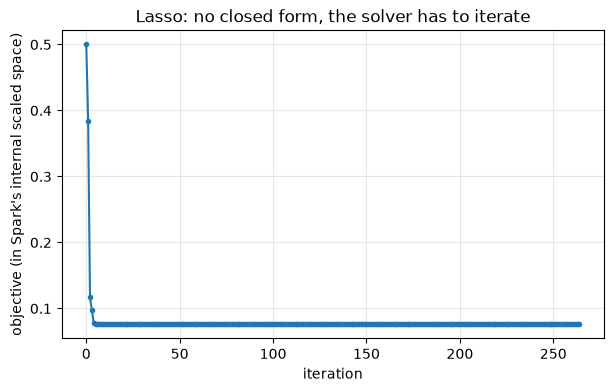

iterations: 265   first: 0.5   last: 0.075722


In [22]:
# What "iterative" looks like: the objective value at every OWL-QN step
hist = fit_lr(0.1, 1.0).summary.objectiveHistory
plt.figure(figsize=(7, 4))
plt.plot(hist, "-o", ms=3)
plt.xlabel("iteration"); plt.ylabel("objective (in Spark's internal scaled space)")
plt.title("Lasso: no closed form, the solver has to iterate")
plt.grid(alpha=0.3); plt.show()
print("iterations:", len(hist), "  first:", round(hist[0], 6), "  last:", round(hist[-1], 6))

## 7. Bias-variance trade-off, measured

* **Bias** = how far the *average* fitted coefficient is from the truth. The penalty pulls
  coefficients towards zero, so **bias grows with $\lambda$**.
* **Variance** = how much the fit jumps around when the training sample changes. The penalty
  stabilizes it, so **variance falls with $\lambda$**.

Test error $\approx$ bias$^2$ + variance + irreducible noise, which is why it forms a **U-shape**:
too little regularization overfits, too much underfits. `RegressionEvaluator` gives us the two
error curves.

In [23]:
curve = spark.createDataFrame(
    [(kind, float(lam), f"{lam:g}", rmse(fits[(kind, lam)], train), rmse(fits[(kind, lam)], test))
     for kind in KINDS for lam in lambdas],
    ["kind", "lam", "lamk", "train_rmse", "test_rmse"]).cache()

(curve.groupBy("lam").pivot("kind", KINDS)
      .agg(F.round(F.first("train_rmse"), 4).alias("train"),
           F.round(F.first("test_rmse"), 4).alias("test"))
      .orderBy("lam").show())

# the best lambda per model: a window function ranking the lambdas by test error
best_by_kind = (curve.withColumn("rank", F.row_number().over(
                        Window.partitionBy("kind").orderBy("test_rmse")))
                     .filter("rank = 1")
                     .select("kind", "lam", F.round("test_rmse", 4).alias("best_test_rmse")))
best_by_kind.show()

+-----+-----------+----------+-----------+----------+
|  lam|ridge_train|ridge_test|lasso_train|lasso_test|
+-----+-----------+----------+-----------+----------+
|  0.0|     0.7723|    1.1557|     0.7723|    1.1557|
|0.001|     0.7725|    1.1545|     0.7726|    1.1519|
|0.003|     0.7733|    1.1536|     0.7728|     1.146|
| 0.01|      0.775|    1.1522|     0.7745|    1.1275|
| 0.03|     0.7769|    1.1485|     0.7874|    1.0901|
|  0.1|     0.7837|    1.1418|     0.8637|    1.0751|
|  0.3|     0.8256|    1.1724|     1.0508|    1.2564|
|  1.0|     1.0488|    1.4582|     2.0718|    2.4235|
|  3.0|     1.5414|    2.0794|     3.5582|    3.9973|
+-----+-----------+----------+-----------+----------+



+-----+---+--------------+
| kind|lam|best_test_rmse|
+-----+---+--------------+
|lasso|0.1|        1.0751|
|ridge|0.1|        1.1418|
+-----+---+--------------+



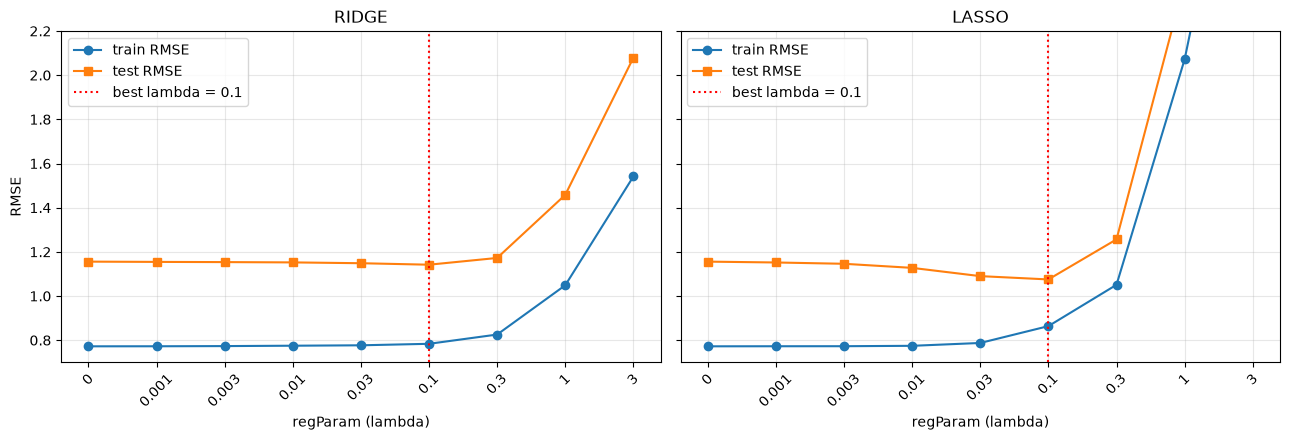

In [24]:
best_lam = {r["kind"]: r["lam"] for r in best_by_kind.collect()}
pts = {(r["kind"], r["lam"]): (r["train_rmse"], r["test_rmse"]) for r in curve.collect()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
x = list(range(len(lambdas)))
for ax, kind in zip(axes, KINDS):
    ax.plot(x, [pts[(kind, l)][0] for l in lambdas], "-o", label="train RMSE")
    ax.plot(x, [pts[(kind, l)][1] for l in lambdas], "-s", label="test RMSE")
    ax.axvline(lambdas.index(best_lam[kind]), color="red", ls=":",
               label=f"best lambda = {best_lam[kind]:g}")
    ax.set_xticks(x); ax.set_xticklabels(LKEYS, rotation=45)
    ax.set_xlabel("regParam (lambda)"); ax.set_title(kind.upper())
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("RMSE"); axes[0].set_ylim(0.7, 2.2)
plt.tight_layout(); plt.show()

Train RMSE only ever goes **up** with $\lambda$ - we are deliberately fitting the training data
worse. Test RMSE first goes **down** (the model stops chasing noise) and then up (the penalty starts
destroying the real signal). The minimum in between is the $\lambda$ we want.

Now separate the two ingredients explicitly. We refit Ridge on 25 bootstrap resamples
(`sample(withReplacement=True)`) for five values of $\lambda$, put all $5\times 25\times 20$
estimates into **one Spark DataFrame**, and let a `groupBy` produce the **bias** (mean estimate -
truth) and the **variance** (spread across the resamples) of every coefficient.

In [25]:
B = 25                                   # bootstrap resamples
BV_LAMBDAS = [0.0, 0.03, 0.1, 0.3, 3.0]  # 5 x 25 = 125 Ridge fits
est_rows = []
for lam in BV_LAMBDAS:
    for i in range(B):
        boot = train.sample(withReplacement=True, fraction=1.0, seed=200 + i)
        m = fit_lr(lam, 0.0, df=boot)                       # Ridge
        est_rows += [(float(lam), f"{lam:g}", i, FEATURES[j], float(b))
                     for j, b in enumerate(m.coefficients.toArray())]

est = spark.createDataFrame(est_rows, ["lam", "lamk", "resample", "feature", "beta"]).cache()

stats2 = (est.groupBy("lam", "lamk", "feature")
             .agg(F.mean("beta").alias("mean_beta"), F.stddev("beta").alias("std_beta"))
             .join(truth, "feature")
             .withColumn("bias", F.col("mean_beta") - F.col("true_beta")).cache())

print("per-coefficient view (the 4 informative columns + 2 noise columns, 3 of the 5 lambdas):")
(stats2.filter(F.col("feature").isin("x1", "x1_dup", "x2", "x3", "noise1", "noise2"))
       .groupBy("fid", "feature").pivot("lamk", ["0", "0.1", "3"])
       .agg(F.round(F.first("bias"), 3).alias("bias"),
            F.round(F.first("std_beta"), 3).alias("std"))
       .orderBy("fid").drop("fid").show(truncate=False))

print(f"totals over all {len(FEATURES)} coefficients:")
(stats2.groupBy("lam")
       .agg(F.round(F.sum(F.abs("bias")), 4).alias("sum_abs_bias"),
            F.round(F.sum("std_beta"), 4).alias("sum_std_variance"))
       .orderBy("lam").show())

# x1 and x1_dup are individually not identifiable (Section 5) -- their SUM is.
# The trade-off shows up just as clearly on that one identified quantity:
print("the collinear pair, looked at through the quantity the data DOES pin down (true sum = 3.0):")
(est.filter(F.col("feature").isin("x1", "x1_dup"))
    .groupBy("lam", "resample").agg(F.sum("beta").alias("pair_sum"))
    .groupBy("lam").agg(F.round(F.mean("pair_sum") - 3.0, 4).alias("pair_sum_bias"),
                        F.round(F.stddev("pair_sum"), 4).alias("pair_sum_std"))
    .orderBy("lam").show())

per-coefficient view (the 4 informative columns + 2 noise columns, 3 of the 5 lambdas):


+-------+------+-----+--------+-------+------+-----+
|feature|0_bias|0_std|0.1_bias|0.1_std|3_bias|3_std|
+-------+------+-----+--------+-------+------+-----+
|x1     |0.952 |3.607|-1.512  |0.086  |-2.131|0.069|
|x1_dup |-0.956|3.689|1.385   |0.135  |0.879 |0.068|
|x2     |0.0   |0.155|0.153   |0.134  |1.196 |0.128|
|x3     |-0.155|0.214|-0.268  |0.213  |-0.975|0.177|
|noise1 |-0.041|0.252|-0.101  |0.203  |-0.158|0.167|
|noise2 |0.214 |0.184|0.218   |0.142  |0.194 |0.073|
+-------+------+-----+--------+-------+------+-----+

totals over all 20 coefficients:


+----+------------+----------------+
| lam|sum_abs_bias|sum_std_variance|
+----+------------+----------------+
| 0.0|      3.7708|         10.6046|
|0.03|      4.4335|          3.6034|
| 0.1|      4.7534|          3.0507|
| 0.3|      5.0447|          2.7514|
| 3.0|      6.9099|          2.1987|
+----+------------+----------------+

the collinear pair, looked at through the quantity the data DOES pin down (true sum = 3.0):


+----+-------------+------------+
| lam|pair_sum_bias|pair_sum_std|
+----+-------------+------------+
| 0.0|      -0.0048|      0.2017|
|0.03|       -0.037|      0.1666|
| 0.1|      -0.1265|      0.1454|
| 0.3|      -0.3202|      0.1239|
| 3.0|      -1.2514|      0.1364|
+----+-------------+------------+



The two totals move in opposite directions as $\lambda$ grows: **`sum_abs_bias` increases while
`sum_std_variance` decreases**. That single table *is* the bias-variance trade-off - and the
test-RMSE curve above is what happens when you add the two up.

The last table makes the same point on the one thing the data can actually identify here: the
**sum** of the collinear pair. Its bias grows steadily with $\lambda$ - the pair is shrunk away from
its true total of 3.0 - while its spread across the resamples shrinks.

## 8. Interpretability and model complexity

For Lasso, "model complexity" has a very concrete meaning: **the number of non-zero coefficients**
- i.e. how many features you have to explain when you present the model. Ridge's complexity is
continuous instead: all features stay, they are just smaller. Joining the sparsity count with the
error curve puts both sides of the trade into one table.

In [26]:
complexity = (paths.groupBy("kind", "lam").agg(F.sum(is_nonzero).alias("n_features"))
                   .join(curve.select("kind", "lam", "test_rmse"), ["kind", "lam"])
                   .cache())

(complexity.groupBy("lam").pivot("kind", KINDS)
           .agg(F.first("n_features").alias("features"),
                F.round(F.first("test_rmse"), 4).alias("test_rmse"))
           .orderBy("lam").show())

+-----+--------------+---------------+--------------+---------------+
|  lam|ridge_features|ridge_test_rmse|lasso_features|lasso_test_rmse|
+-----+--------------+---------------+--------------+---------------+
|  0.0|            20|         1.1557|            20|         1.1557|
|0.001|            20|         1.1545|            19|         1.1519|
|0.003|            20|         1.1536|            19|          1.146|
| 0.01|            20|         1.1522|            16|         1.1275|
| 0.03|            20|         1.1485|            16|         1.0901|
|  0.1|            20|         1.1418|            10|         1.0751|
|  0.3|            20|         1.1724|             4|         1.2564|
|  1.0|            20|         1.4582|             3|         2.4235|
|  3.0|            20|         2.0794|             0|         3.9973|
+-----+--------------+---------------+--------------+---------------+



In [27]:
# A common rule: among the models that are (almost) as good as the best one, take the SIMPLEST.
lasso_cx = complexity.filter(F.col("kind") == "lasso")
best_rmse = lasso_cx.agg(F.min("test_rmse")).first()[0]

good = lasso_cx.filter(F.col("test_rmse") <= 1.02 * best_rmse)     # within 2% of the best
print("lambdas within 2% of the best test RMSE:",
      [r["lam"] for r in good.orderBy("lam").select("lam").collect()])

chosen = good.orderBy("n_features", "lam").first()
print(f"\nCHOSEN  Lasso, lambda = {chosen['lam']:g}   (test RMSE = {chosen['test_rmse']:.4f},"
      f" {chosen['n_features']} of {len(FEATURES)} features)")


# the surviving terms, read straight out of the coefficient DataFrame
def equation(kind, lam, intercept):
    terms = (paths.filter((F.col("kind") == kind) & (F.col("lam") == lam) & (F.abs("beta") > ZERO))
                  .orderBy("fid").collect())
    return f"{intercept:+.3f} " + " ".join(f"{r['beta']:+.3f}*{r['feature']}" for r in terms)


print("   y_hat =", equation("lasso", chosen["lam"], fits[("lasso", chosen["lam"])].intercept))
print(f"\n        OLS,   lambda = 0     (test RMSE = {rmse(ols, test):.4f},"
      f" all {len(FEATURES)} features)")
print("   y_hat =", equation("lasso", 0.0, ols.intercept))
print("\n        truth =  +0.000 +3.000*x1 -2.000*x2 +1.500*x3")

lambdas within 2% of the best test RMSE: [0.03, 0.1]

CHOSEN  Lasso, lambda = 0.1   (test RMSE = 1.0751, 10 of 20 features)
   y_hat = -0.113 +1.661*x1 +1.134*x1_dup -1.772*x2 +1.201*x3 -0.041*noise1 +0.099*noise2 -0.063*noise3 +0.034*noise8 -0.051*noise9 -0.005*noise12



        OLS,   lambda = 0     (test RMSE = 1.1557, all 20 features)
   y_hat = -0.204 +3.546*x1 -0.515*x1_dup -1.980*x2 +1.347*x3 -0.041*noise1 +0.190*noise2 -0.148*noise3 -0.025*noise4 +0.138*noise5 +0.057*noise6 +0.118*noise7 +0.129*noise8 -0.209*noise9 -0.040*noise10 -0.130*noise11 -0.151*noise12 -0.190*noise13 -0.001*noise14 -0.083*noise15 -0.005*noise16

        truth =  +0.000 +3.000*x1 -2.000*x2 +1.500*x3


## 9. The penalty is scale-sensitive: `standardization`

$\sum_j\beta_j^2$ adds up coefficients of different features, but a coefficient means "effect per
unit of that feature". Measure `x3` in millimetres instead of metres and its coefficient shrinks
1000x - so the penalty stops noticing it, while every other feature is still penalized at full
strength. **The model you get would depend on the units you happened to choose.**

That is why `LinearRegression` uses **`standardization=True` by default**: Spark scales every
feature to unit variance internally, penalizes those comparable coefficients, and converts the
result back to the original units for you.

In [28]:
# Same data, but x3 is now measured in units 1000x smaller
scaled = assembler.transform(raw.withColumn("x3", F.col("x3") * 1000.0))
s_train, s_test = scaled.randomSplit([0.03, 0.97], seed=42)      # identical split
s_train.cache()

lam = 0.1
rescaled = {}
for std_flag in [True, False]:
    rescaled[f"rescaled_std_{std_flag}"] = LinearRegression(
        featuresCol="features", labelCol=LABEL, regParam=lam, elasticNetParam=0.0,
        maxIter=500, standardization=std_flag).fit(s_train)

KEYS = ["original_std_True", "rescaled_std_True", "rescaled_std_False"]

# put x3 back into the original units so that all three fits are comparable
comp = (coefs_of({"original_std_True": fits[("ridge", lam)], **rescaled})
        .withColumn("beta", F.when((F.col("model") != "original_std_True")
                                   & (F.col("feature") == "x3"),
                                   F.col("beta") * 1000.0).otherwise(F.col("beta"))))

wide_comp = comp.groupBy("fid", "feature").pivot("model", KEYS).agg(F.first("beta")).cache()

(wide_comp.orderBy("fid").drop("fid")
          .select("feature", *[F.round(k, 4).alias(k) for k in KEYS])
          .show(25, truncate=False))

(wide_comp.select(
    F.format_string("%.3e", F.max(F.abs(F.col(KEYS[1]) - F.col(KEYS[0])))).alias("max_change_std_True"),
    F.format_string("%.3e", F.max(F.abs(F.col(KEYS[2]) - F.col(KEYS[0])))).alias("max_change_std_False"))
 .show(truncate=False))

+-------+-----------------+-----------------+------------------+
|feature|original_std_True|rescaled_std_True|rescaled_std_False|
+-------+-----------------+-----------------+------------------+
|x1     |1.5304           |1.5304           |1.5306            |
|x1_dup |1.4182           |1.4182           |1.4142            |
|x2     |-1.8767          |-1.8767          |-1.8824           |
|x3     |1.2617           |1.2617           |1.3158            |
|noise1 |-0.0737          |-0.0737          |-0.0552           |
|noise2 |0.1896           |0.1896           |0.1964            |
|noise3 |-0.1423          |-0.1423          |-0.1363           |
|noise4 |0.0155           |0.0155           |0.0143            |
|noise5 |0.1227           |0.1227           |0.1231            |
|noise6 |0.0356           |0.0356           |0.0376            |
|noise7 |0.1083           |0.1083           |0.1022            |
|noise8 |0.1235           |0.1235           |0.1252            |
|noise9 |-0.1594         

With `standardization=True` the fit on the rescaled data is **identical** to the fit on the original
data down to machine precision: the result does not depend on your choice of units. With
`standardization=False` the coefficients change, because the rescaled `x3` is now effectively
un-penalized while everything else is penalized as before.

**Rule of thumb: leave `standardization=True`, or standardize the features yourself with
`StandardScaler`.**

## 10. Choosing $\lambda$ and $\alpha$ properly: cross-validation

$\lambda$ and $\alpha$ are **hyper-parameters** - they cannot be read off the training loss, which
always prefers $\lambda = 0$ (Section 2). And we are not allowed to pick them by looking at the test
set either: that would leak the test data into the model. The standard recipe is
`ParamGridBuilder` + `CrossValidator`: split the *training* set into $k$ folds, train every
combination $k$ times, keep the combination with the best average validation error.

In [29]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr = LinearRegression(featuresCol="features", labelCol=LABEL, maxIter=500)

grid = (ParamGridBuilder()
        .addGrid(lr.regParam,        [0.003, 0.01, 0.03, 0.1, 0.3])   # lambda
        .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])                 # ridge / elastic net / lasso
        .build())
print("grid:", len(grid), "combinations x 4 folds =", len(grid) * 4, "model fits")

cv = CrossValidator(estimator=lr,
                    estimatorParamMaps=grid,
                    evaluator=RegressionEvaluator(labelCol=LABEL, metricName="rmse"),
                    numFolds=4, parallelism=1, seed=7)

cv_model = cv.fit(train)

grid: 15 combinations x 4 folds = 60 model fits


In [30]:
cv_results = spark.createDataFrame(
    [(float(pm[lr.regParam]), f"alpha={pm[lr.elasticNetParam]:g}", float(metric))
     for pm, metric in zip(grid, cv_model.avgMetrics)],
    ["regParam", "elasticNet", "cv_rmse"])

print("cross-validated RMSE for every (lambda, alpha) combination:")
(cv_results.groupBy("regParam").pivot("elasticNet", ["alpha=0", "alpha=0.5", "alpha=1"])
           .agg(F.round(F.first("cv_rmse"), 4))
           .orderBy("regParam").show())

best = cv_model.bestModel
print("best regParam          :", best.getRegParam())
print("best elasticNetParam   :", best.getElasticNetParam())
print("test RMSE, tuned model : %.4f" % rmse(best, test))
print("test RMSE, plain OLS   : %.4f" % rmse(ols, test))

show_with_truth(wide(coefs_of({"cross_validated": best, "OLS": ols}), ["cross_validated", "OLS"]))

cross-validated RMSE for every (lambda, alpha) combination:


+--------+-------+---------+-------+
|regParam|alpha=0|alpha=0.5|alpha=1|
+--------+-------+---------+-------+
|   0.003| 1.3128|   1.3054| 1.2973|
|    0.01|  1.303|   1.2779| 1.2601|
|    0.03| 1.2898|   1.2212| 1.1804|
|     0.1| 1.2619|   1.1005| 1.0512|
|     0.3| 1.2485|   1.0878| 1.1506|
+--------+-------+---------+-------+

best regParam          : 0.1
best elasticNetParam   : 1.0
test RMSE, tuned model : 1.0751
test RMSE, plain OLS   : 1.1557


+-------+----+---------------+-------+
|feature|TRUE|cross_validated|OLS    |
+-------+----+---------------+-------+
|x1     |3.0 |1.6613         |3.5458 |
|x1_dup |0.0 |1.1341         |-0.5152|
|x2     |-2.0|-1.7717        |-1.9803|
|x3     |1.5 |1.2005         |1.3472 |
|noise1 |0.0 |-0.0408        |-0.0412|
|noise2 |0.0 |0.0992         |0.1895 |
|noise3 |0.0 |-0.0632        |-0.1476|
|noise4 |0.0 |0.0            |-0.0249|
|noise5 |0.0 |0.0            |0.1383 |
|noise6 |0.0 |0.0            |0.0571 |
|noise7 |0.0 |0.0            |0.1184 |
|noise8 |0.0 |0.0343         |0.1287 |
|noise9 |0.0 |-0.0513        |-0.2089|
|noise10|0.0 |0.0            |-0.0399|
|noise11|0.0 |0.0            |-0.1298|
|noise12|0.0 |-0.0053        |-0.151 |
|noise13|0.0 |0.0            |-0.1898|
|noise14|0.0 |0.0            |-9.0E-4|
|noise15|0.0 |0.0            |-0.0829|
|noise16|0.0 |0.0            |-0.005 |
+-------+----+---------------+-------+



## 11. The same two knobs elsewhere in MLlib

`regParam` / `elasticNetParam` are not specific to `LinearRegression`. `LogisticRegression` has
exactly the same pair, `LinearSVC` and `GeneralizedLinearRegression` have `regParam` (L2 only):
add a penalty on $\beta$ to whatever loss the model uses. Below, L1 makes a *classifier* sparse.

In [31]:
clf = data.withColumn("label", (F.col(LABEL) > 0).cast("double"))
c_train, c_test = clf.randomSplit([0.03, 0.97], seed=42)

logit = {}
for a, name in [(0.0, "L2_ridge_like"), (1.0, "L1_lasso_like")]:
    logit[name] = LogisticRegression(featuresCol="features", labelCol="label",
                                     regParam=0.05, elasticNetParam=a).fit(c_train)

logit_coefs = coefs_of(logit).cache()

wide(logit_coefs, list(logit)).orderBy("fid").drop("fid").show(25, truncate=False)

(logit_coefs.groupBy("model")
            .agg(F.sum(F.when(F.abs("beta") > ZERO, 1).otherwise(0)).alias("non_zero"),
                 F.sum(F.when(F.abs("beta") <= ZERO, 1).otherwise(0)).alias("exact_zeros"))
            .orderBy("model").show())

+-------+-------------+-------------+
|feature|L2_ridge_like|L1_lasso_like|
+-------+-------------+-------------+
|x1     |1.0224       |1.0584       |
|x1_dup |1.0119       |0.9052       |
|x2     |-0.4972      |-0.5011      |
|x3     |0.6799       |0.5327       |
|noise1 |0.2519       |0.0          |
|noise2 |0.2755       |0.0425       |
|noise3 |0.1824       |0.0          |
|noise4 |0.2337       |0.0          |
|noise5 |0.0213       |0.0          |
|noise6 |-0.4504      |-0.1273      |
|noise7 |0.1996       |0.0          |
|noise8 |0.3049       |0.1388       |
|noise9 |0.1102       |0.0          |
|noise10|0.0949       |0.0          |
|noise11|0.2977       |0.0          |
|noise12|-0.0232      |0.0          |
|noise13|0.3264       |0.0126       |
|noise14|0.1417       |0.0          |
|noise15|-0.0209      |0.0          |
|noise16|0.2395       |0.0175       |
+-------+-------------+-------------+

+-------------+--------+-----------+
|        model|non_zero|exact_zeros|
+------------

## 12. Recap

| **Aspect**                           | **Ridge Regularization**                                                                                                                                                                              | **Lasso Regularization**                                                                                                                                                                                  |
|--------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Penalty Term**                     | - Employs an L2 norm penalty: $ \lambda \sum_{j=1}^p \beta_j^2 $ . <br> - Adds the sum of squared coefficients to the loss function.                                                             | - Employs an L1 norm penalty $ \lambda \sum_{j=1}^p \|\beta_j\| $ . <br> - Adds the sum of the absolute values of coefficients to the loss function.                                                |
| **Coefficient Shrinkage vs. Selection** | - Shrinks all coefficients continuously towards zero. <br> - Does not force any coefficient to be exactly zero, thus retaining all predictors in the model.                                       | - Encourages sparsity by driving some coefficients exactly to zero. <br> - Performs variable selection by effectively eliminating less important predictors from the model.                        |
| **Handling of Correlated Predictors** | - Distributes the coefficient weight among correlated predictors, reducing their magnitude uniformly. <br> - Useful when it is believed that all predictors contribute some information.           | - May select one predictor from a group of correlated predictors while setting others to zero. <br> - Can lead to a more interpretable model, though it might be less stable with multicollinearity. |
| **Computational Considerations**     | - Often has a closed-form solution (via the normal equations), making it computationally straightforward.                                                                                            | - Lacks a closed-form solution due to the non-differentiability of the L1 norm. <br> - Requires iterative optimization techniques (e.g., coordinate descent) to determine the optimal coefficients.     |
| **Bias-Variance Trade-off**          | - Primarily reduces variance by uniformly shrinking coefficients, resulting in a moderate increase in bias.                                                                                           | - May result in higher bias if important predictors are omitted, but often substantially reduces variance through model simplification and sparsity.                                                     |
| **Interpretability and Model Complexity** | - Retains all predictors, which may complicate model interpretation when many predictors are involved. <br> - More suitable when it is believed that all predictors have some effect on the response. | - Yields a sparse model by selecting only a subset of predictors. <br> - Enhances interpretability and simplifies the model, although over-regularization may lead to the exclusion of relevant predictors.  |

### PySpark cheat sheet

```python
LinearRegression(regParam=lam, elasticNetParam=0.0)   # Ridge / L2
LinearRegression(regParam=lam, elasticNetParam=1.0)   # Lasso / L1
LinearRegression(regParam=lam, elasticNetParam=0.5)   # Elastic Net
LinearRegression(regParam=0.0)                        # no regularization (OLS)
```

* `regParam` ($\lambda$) = **how much**, `elasticNetParam` ($\alpha$) = **which kind**.
* The intercept is never penalized; `standardization=True` (default) makes the fit invariant to the
  units of the features.
* Ridge = one closed-form solve (`solver="normal"`); Lasso = iterative (OWL-QN) only.
* Regularization helps when the training set is small relative to the number of features, and when
  many of those features are useless. With plenty of rows per feature, $\lambda \to 0$ is fine.
* Always choose $\lambda$ and $\alpha$ with `CrossValidator`, never on the training loss and never
  on the test set.

### The Spark patterns used along the way

| Pattern | Where |
|---|---|
| `spark.range` + `F.randn` + `withColumn` to build a dataset | Section 1 |
| `df.stat.corr`, `stddev_pop`, `randomSplit`, `cache` | Section 1 |
| the loss aggregated over the data (`F.sum`, `F.pow`) | Section 2 |
| a column expression that scores *any* coefficient vector | Section 2 |
| coefficients kept in a LONG DataFrame + `groupBy` / `pivot` / `join` | Sections 2-11 |
| `Window.partitionBy()` for global shares, `row_number` for "best per group" | Sections 3, 7 |
| `RDD.treeAggregate` for `X^T X` and `X^T y` in one pass | Section 6 |
| `sample(withReplacement=True)` for bootstrap resampling | Sections 5, 7 |
| `RegressionEvaluator`, `ParamGridBuilder`, `CrossValidator` | Sections 7, 10 |

In [32]:
# spark.stop()